In [6]:
import pandas as pd

from Custom_nn import NeuralNetwork
from PyTorch_nn import TorchModel
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os
from sklearn.model_selection import train_test_split


In [7]:
data_path = os.path.join(os.getcwd(), r'data\Iris.csv')
df_iris = pd.read_csv(data_path)

df_iris.set_index('Id', inplace=True)

In [8]:
display(df_iris)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
146,6.7,3.0,5.2,2.3,Iris-virginica
147,6.3,2.5,5.0,1.9,Iris-virginica
148,6.5,3.0,5.2,2.0,Iris-virginica


In [9]:
#nn = NeuralNetwork([2, 3, 3, 1], ['sigmoid','sigmoid','sigmoid'], lr=0.1, epochs=500)
#nn.train(X, Y, print_every=50)
#preds = nn.predict(X_test)

### Brief Pre-processing

In [10]:
X = df_iris.drop('Species', axis=1)
y = df_iris['Species']

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

std = StandardScaler()
X_train = std.fit_transform(X_train)
X_test = std.transform(X_test)


### PyTorch Implementation

In [11]:

# convert features to tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

#convert target to tensor
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)


In [12]:
# import PyTorch NN 
torch.manual_seed(69)
torch_model = TorchModel()

In [13]:
# criterion setup
criterion = nn.CrossEntropyLoss()
#Choose optimizer --> Adam (popular), lr --> learning rate
optimizer = torch.optim.Adam(torch_model.parameters(), lr= 0.01)# the lower the lr, the longer it takes

#### Train Torch model

Epoch: 0 and loss: 1.1473088264465332
Epoch: 10 and loss: 0.9968990683555603
Epoch: 20 and loss: 0.6897786259651184
Epoch: 30 and loss: 0.442170113325119
Epoch: 40 and loss: 0.30639058351516724
Epoch: 50 and loss: 0.2106972336769104
Epoch: 60 and loss: 0.1440705507993698
Epoch: 70 and loss: 0.09059811383485794
Epoch: 80 and loss: 0.06673868000507355
Epoch: 90 and loss: 0.05839831382036209


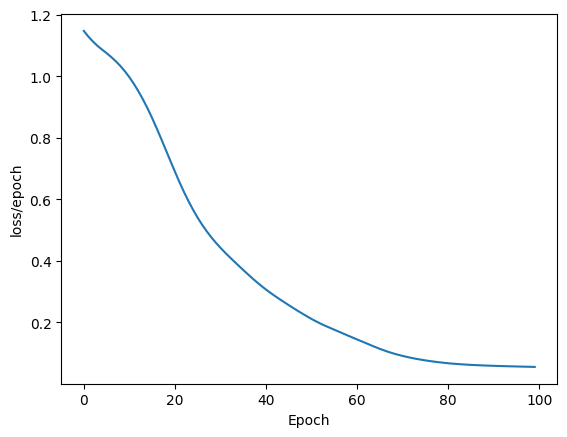

In [14]:
# number of Epochs
epochs = 100
losses = [] # list of losses

for i in range(epochs):
    y_pred = torch_model.forward(X_train)
    #measure error
    loss = criterion(y_pred, y_train)
    losses.append(loss.detach().numpy())
    
    
    if i % 10 == 0:
        print(f'Epoch: {i} and loss: {loss}') # every 10 epochs
        
    #backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    

plt.plot(range(epochs), losses)
plt.ylabel("loss/epoch")
plt.xlabel('Epoch')
plt.show()

#### Evaluate Pytorch

In [15]:
with torch.no_grad(): # turn off backprop
    y_eval = torch_model.forward(X_test)
    loss = criterion(y_eval, y_test) # find error in trained NN 
    
print(loss)

tensor(0.0318)


In [16]:
from sklearn.metrics import accuracy_score, precision_score

with torch.no_grad():
    y_logits = torch_model(X_test)
    y_pred = torch.argmax(y_logits, dim=1)

y_pred_np = y_pred.numpy()
y_test_np = y_test.numpy()

accuracy = accuracy_score(y_test_np, y_pred_np)
print(f"\nTest Accuracy: {accuracy:.4f}")

precision = precision_score(y_test_np, y_pred_np, average='macro')
print(f"Test Precision (macro-averaged): {precision:.4f}")


Test Accuracy: 1.0000
Test Precision (macro-averaged): 1.0000
